# SampleRepertoire — Overview

Loads multi-locus paired immune repertoires from the `isalgo/airr_benchmark`
SRA tarball and visualises the per-chain composition of each sample as two
stacked bar charts:

* **Top** — total read count (`duplicate_count`) per locus per sample
* **Bottom** — unique clonotype count per locus per sample

Data source: `airr_benchmark/sra/samples.tar.gz`
Metadata: `airr_benchmark/sra/meta.tsv` (columns: `PMID`, `Run`, `BioProject`, `Sample`)

In [1]:
import importlib.metadata as _meta
import sys as _sys
print(f"Python {_sys.version.split()[0]}")
for _pkg in ["mirpy-lib", "numpy", "pandas", "matplotlib", "scipy", "polars"]:
    try:
        print(f"  {_pkg}: {_meta.version(_pkg)}")
    except _meta.PackageNotFoundError:
        pass

import sys
from pathlib import Path

repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

Python 3.12.12
  mirpy-lib: 1.1.0
  numpy: 1.26.4
  pandas: 3.0.3
  matplotlib: 3.10.9
  scipy: 1.17.1
  polars: 1.40.1


In [2]:
import io
import tarfile
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

from mir.common.clonotype import Clonotype
from mir.common.repertoire import SampleRepertoire, infer_locus
from mir.utils.notebook_assets import ensure_airr_benchmark, find_airr_benchmark_sra_meta

/Users/mikesh/vcs/mirpy/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [3]:
benchmark_root = ensure_airr_benchmark(repo_root, allow_patterns=["sra/**"])
TARBALL, META_CSV = find_airr_benchmark_sra_meta(benchmark_root)

# Loci shown in the plot (ordered and coloured consistently)
LOCI_ORDER = ["TRA", "TRB", "TRG", "TRD", "IGH", "IGK", "IGL"]
LOCI_COLORS = {
    "TRA": "#4e79a7",
    "TRB": "#f28e2b",
    "TRG": "#59a14f",
    "TRD": "#76b7b2",
    "IGH": "#e15759",
    "IGK": "#b07aa1",
    "IGL": "#ff9da7",
}

# Max samples shown in stacked bar charts (pie charts always use the full dataset)
N_DISPLAY = 30

## Load SampleRepertoires

Each TSV in the tarball follows the AIRR Rearrangement Schema with `v_call` / `j_call` columns.  
Locus is inferred from the gene prefix (`TRBV…` → `TRB`, `TRAV…` → `TRA`, etc.).

In [4]:
_CALL_RENAMES = {"v_call": "v_gene", "j_call": "j_gene", "c_call": "c_gene"}
_PREFIX_TO_LOCUS: dict[str, str] = {
    "TRA": "TRA", "TRB": "TRB", "TRG": "TRG", "TRD": "TRD",
    "IGH": "IGH", "IGK": "IGK", "IGL": "IGL",
}

# Single sequential pass through the tarball — avoids repeated seeks in .tar.gz.
_run_frames: dict[str, pd.DataFrame] = {}
with tarfile.open(TARBALL, mode="r:gz") as tar:
    for member in tar.getmembers():
        if not member.name.endswith(".tsv") or member.size == 0:
            continue
        run_id = member.name.replace("./", "").replace(".tsv", "")
        fh = tar.extractfile(member)
        if fh is None:
            continue
        df = pd.read_csv(fh, sep="\t").rename(columns=_CALL_RENAMES)
        # Vectorised locus inference from the V-gene prefix (no iterrows).
        df["locus"] = (
            df["v_gene"].fillna("").str[:3].str.upper()
            .map(_PREFIX_TO_LOCUS).fillna("")
        )
        _run_frames[run_id] = df

meta_df = pd.read_csv(META_CSV, sep="\t")
meta_df = meta_df[meta_df["Run"].isin(_run_frames)]
sample_map = meta_df.groupby("Sample")["Run"].apply(list).to_dict()

sample_repertoires: list[SampleRepertoire] = []
for sample_id, run_ids in sample_map.items():
    frames = [_run_frames[r] for r in run_ids if r in _run_frames]
    if not frames:
        continue
    merged = pd.concat(frames, ignore_index=True) if len(frames) > 1 else frames[0]
    sr = SampleRepertoire.from_pandas(merged, locus_column="locus", sample_id=sample_id)
    sample_repertoires.append(sr)

# Sort richest samples first so bar-chart selection is stable.
sample_repertoires.sort(key=lambda sr: sr.clonotype_count, reverse=True)

print(f"Loaded {len(sample_repertoires)} samples from {TARBALL}")
print(f"Total clonotypes : {sum(sr.clonotype_count for sr in sample_repertoires):,}")
print(f"Total reads      : {sum(sr.duplicate_count  for sr in sample_repertoires):,}")

Loaded 1764 samples from /Users/mikesh/vcs/mirpy/notebooks/assets/large/airr_benchmark/sra/samples.tar.gz
Total clonotypes : 874,440
Total reads      : 1,339,480


In [5]:
# sample_repertoires already loaded in the previous cell.
samples = sample_repertoires
print(f"{len(samples)} samples ready for analysis")

1764 samples ready for analysis


## Build summary table

One row per `(sample_id, locus)` with `duplicate_count` and `clonotype_count`.

In [6]:
def build_summary(samples: list[SampleRepertoire]) -> pd.DataFrame:
    """Return a long-form DataFrame with per-locus counts for every sample."""
    rows = []
    for sr in samples:
        for locus, lr in sr.loci.items():
            rows.append({
                "sample_id":       sr.sample_id,
                "locus":           locus,
                "duplicate_count": lr.duplicate_count,
                "clonotype_count": lr.clonotype_count,
            })
    return pd.DataFrame(rows)


summary = build_summary(samples)
summary.head()

,sample_id,locus,duplicate_count,clonotype_count
0,SRX14820701,TRD,19,13
1,SRX14820701,TRA,216,188
2,SRX14820701,IGH,984,746
3,SRX14820701,TRB,305,276
4,SRX14820701,TRG,47,37


### Locus coverage

Which loci are absent from at least one sample?

In [7]:
coverage = (
    summary
    .pivot_table(index="sample_id", columns="locus", values="clonotype_count", fill_value=0)
    .reindex(columns=[l for l in LOCI_ORDER if l in summary["locus"].unique()], fill_value=0)
)

missing_per_sample = (coverage == 0).sum(axis=1)
samples_with_gaps  = missing_per_sample[missing_per_sample > 0]

print(f"{len(samples_with_gaps)}/{len(coverage)} samples have at least one missing locus\n")
print("Missing locus frequency across samples:")
for locus in coverage.columns:
    n_miss = int((coverage[locus] == 0).sum())
    pct    = 100 * n_miss / len(coverage)
    print(f"  {locus}: absent in {n_miss:4d}/{len(coverage)} samples ({pct:.1f}%)")

974/1763 samples have at least one missing locus

Missing locus frequency across samples:
  TRA: absent in  271/1763 samples (15.4%)
  TRB: absent in  274/1763 samples (15.5%)
  TRG: absent in  324/1763 samples (18.4%)
  TRD: absent in  868/1763 samples (49.2%)
  IGH: absent in  366/1763 samples (20.8%)
  IGK: absent in  176/1763 samples (10.0%)
  IGL: absent in  190/1763 samples (10.8%)


## Stacked bar charts

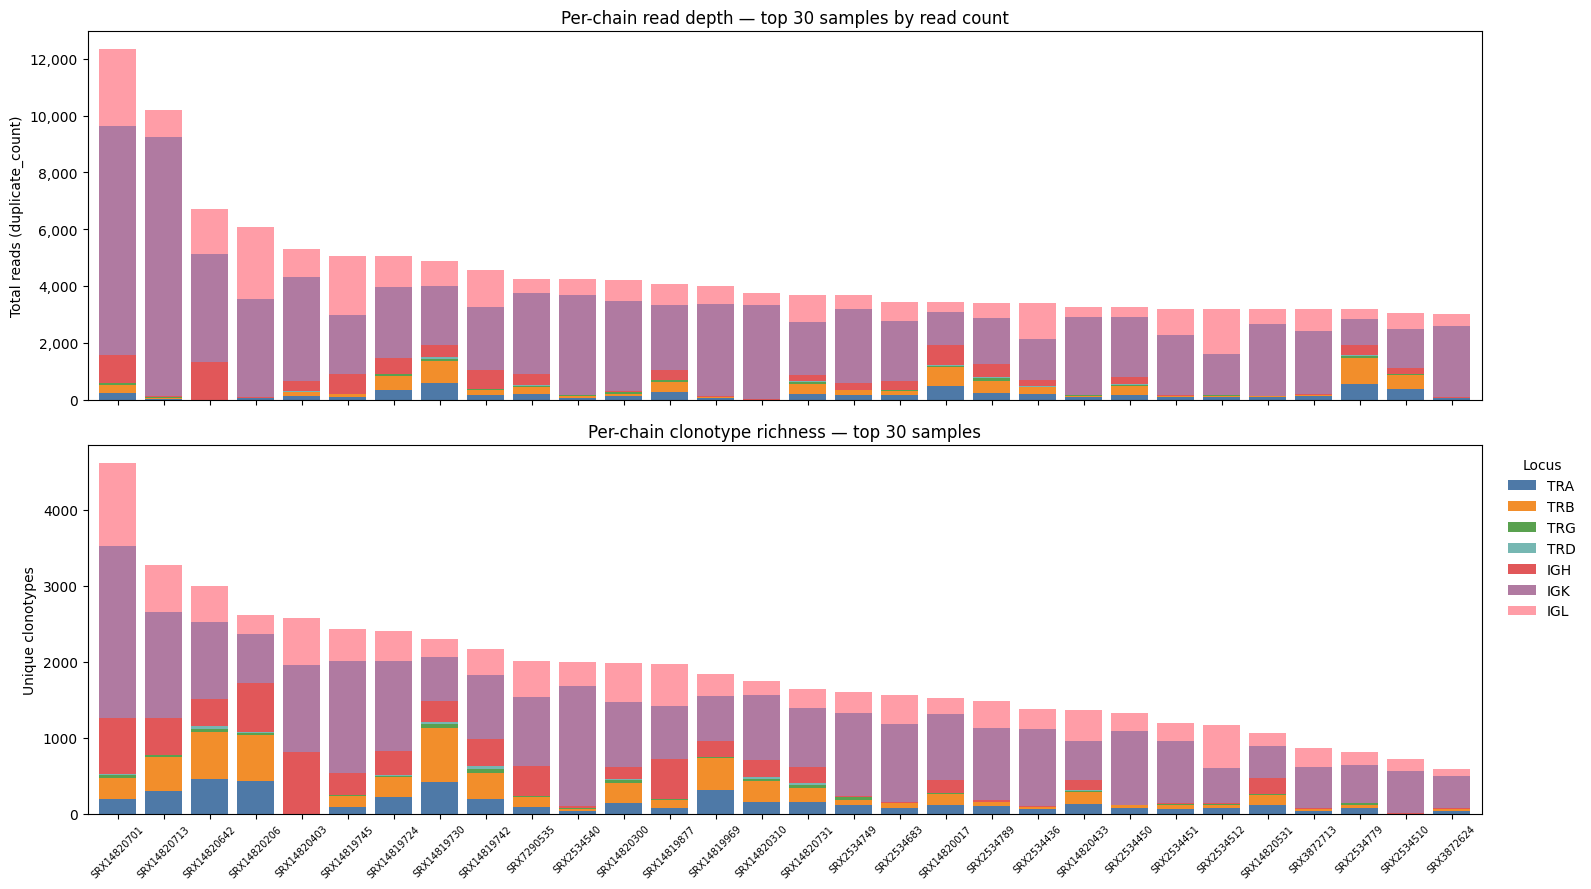

In [8]:
def _pivot_sorted(summary: pd.DataFrame, value_col: str) -> pd.DataFrame:
    """Pivot *summary* and sort rows by total value descending."""
    present_loci = [l for l in LOCI_ORDER if l in summary["locus"].unique()]
    wide = (
        summary
        .pivot_table(index="sample_id", columns="locus", values=value_col, fill_value=0)
        .reindex(columns=present_loci, fill_value=0)
    )
    return wide.loc[wide.sum(axis=1).sort_values(ascending=False).index]


def plot_stacked_bars(
    summary: pd.DataFrame,
    *,
    n_display: int = N_DISPLAY,
    figsize: tuple[int, int] = (16, 9),
) -> None:
    """Stacked bar charts of read depth and clonotype richness for the top samples.

    Selects the *n_display* samples with the highest total read count,
    sorted richest-first, and labels each bar with its sample ID.

    Parameters
    ----------
    summary:
        Long-form DataFrame with columns ``sample_id``, ``locus``,
        ``duplicate_count``, ``clonotype_count``.
    n_display:
        Number of richest samples to show.
    figsize:
        Overall figure size ``(width, height)`` in inches.
    """
    top_ids = (
        summary.groupby("sample_id")["duplicate_count"].sum()
        .nlargest(n_display).index
    )
    sub = summary[summary["sample_id"].isin(top_ids)]

    reads      = _pivot_sorted(sub, "duplicate_count")
    clonotypes = _pivot_sorted(sub, "clonotype_count")
    colors     = [LOCI_COLORS[l] for l in reads.columns]
    n          = len(reads)

    fig, (ax_reads, ax_clones) = plt.subplots(2, 1, figsize=figsize, sharex=True)

    reads.plot(kind="bar", stacked=True, ax=ax_reads,
               color=colors, legend=False, width=0.8)
    ax_reads.set_ylabel("Total reads (duplicate_count)")
    ax_reads.set_title(f"Per-chain read depth — top {n} samples by read count")
    ax_reads.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax_reads.tick_params(axis="x", labelbottom=False)

    clonotypes.plot(kind="bar", stacked=True, ax=ax_clones,
                    color=colors, legend=True, width=0.8)
    ax_clones.set_ylabel("Unique clonotypes")
    ax_clones.set_title(f"Per-chain clonotype richness — top {n} samples")
    ax_clones.set_xlabel("")
    ax_clones.tick_params(axis="x", rotation=45, labelsize=7)
    ax_clones.legend(title="Locus", bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)

    fig.tight_layout()
    plt.show()


plot_stacked_bars(summary)

## Locus coverage pie charts

For each chain, samples are classified as **missing** (locus absent), **< 100 reads** (low coverage), or **≥ 100 reads** (adequate).  All samples are included.

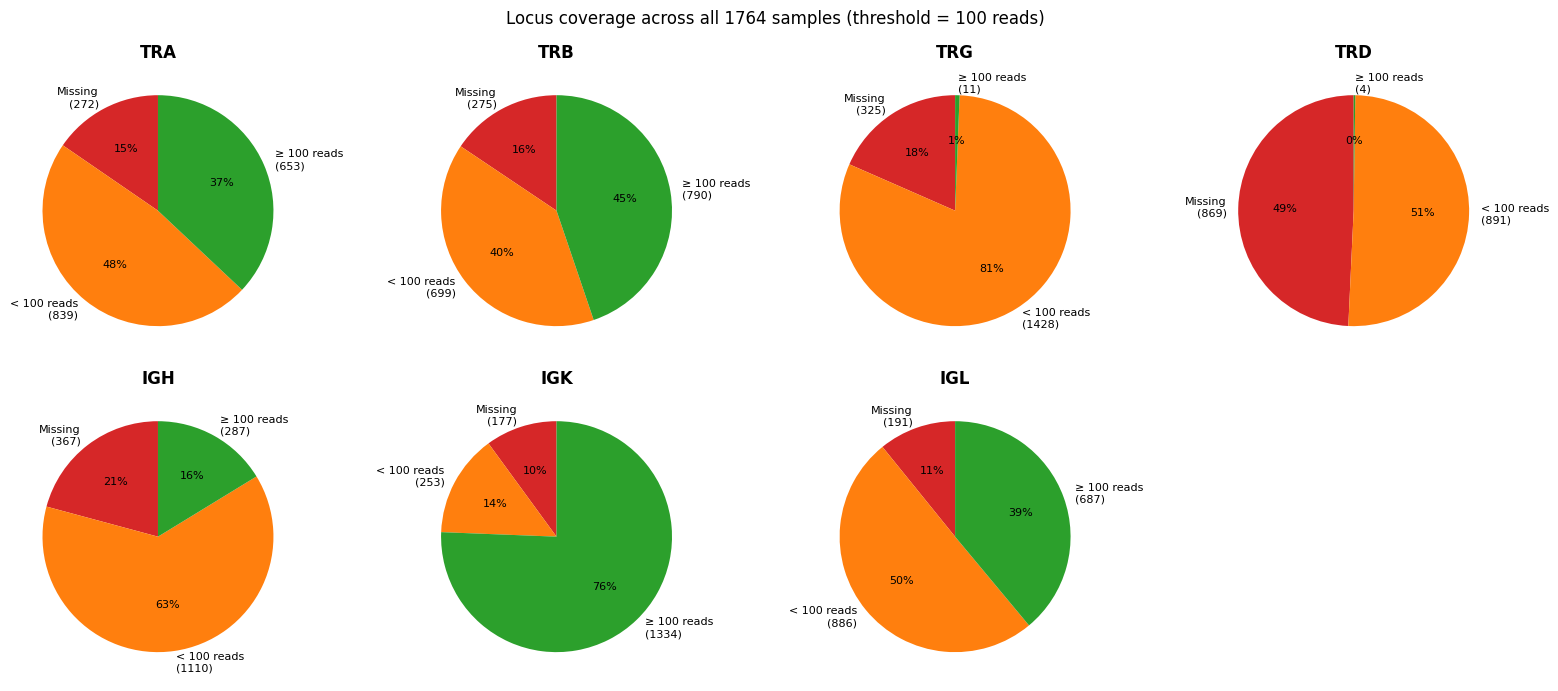

In [9]:
def plot_locus_coverage_pies(
    summary: pd.DataFrame,
    n_samples: int,
    *,
    low_reads_threshold: int = 100,
    figsize: tuple[int, int] | None = None,
) -> None:
    """Pie charts showing missing / low-read / adequate coverage per locus.

    For every locus in LOCI_ORDER that appears in the data, samples are
    split into three categories:

    * **Missing** — locus absent from the sample entirely.
    * **< threshold** — locus detected but total reads below *low_reads_threshold*.
    * **≥ threshold** — adequately sequenced.

    Parameters
    ----------
    summary:
        Long-form per-(sample, locus) DataFrame from :func:`build_summary`.
    n_samples:
        Total number of samples (denominator for the missing category).
    low_reads_threshold:
        Read count below which a present locus is considered low-coverage.
    figsize:
        Figure size; auto-computed when ``None``.
    """
    present_loci = [l for l in LOCI_ORDER if l in summary["locus"].unique()]
    n_cols = 4
    n_rows = (len(present_loci) + n_cols - 1) // n_cols
    if figsize is None:
        figsize = (4 * n_cols, 3.5 * n_rows)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes_flat = axes.flatten() if hasattr(axes, "flatten") else [axes]

    # Missing=red, low=orange, adequate=green
    PIE_COLORS = ["#d62728", "#ff7f0e", "#2ca02c"]

    for i, locus in enumerate(present_loci):
        ax = axes_flat[i]
        locus_reads = summary.loc[summary["locus"] == locus, "duplicate_count"]
        n_missing  = n_samples - len(locus_reads)          # locus absent from sample
        n_low      = int(((locus_reads > 0) & (locus_reads < low_reads_threshold)).sum())
        n_adequate = int((locus_reads >= low_reads_threshold).sum())
        # Fold zero-read detections into the missing bucket.
        n_missing += int((locus_reads == 0).sum())

        categories = [
            (f"Missing\n({n_missing})",                           n_missing,  PIE_COLORS[0]),
            (f"< {low_reads_threshold} reads\n({n_low})",         n_low,      PIE_COLORS[1]),
            (f"≥ {low_reads_threshold} reads\n({n_adequate})",    n_adequate, PIE_COLORS[2]),
        ]
        labels = [c[0] for c in categories if c[1] > 0]
        sizes  = [c[1] for c in categories if c[1] > 0]
        colors = [c[2] for c in categories if c[1] > 0]

        ax.pie(sizes, labels=labels, colors=colors,
               autopct="%1.0f%%", startangle=90,
               textprops={"fontsize": 8})
        ax.set_title(locus, fontweight="bold")

    for j in range(len(present_loci), len(axes_flat)):
        axes_flat[j].set_visible(False)

    fig.suptitle(
        f"Locus coverage across all {n_samples} samples "
        f"(threshold = {low_reads_threshold} reads)",
        fontsize=12,
    )
    fig.tight_layout()
    plt.show()


plot_locus_coverage_pies(summary, n_samples=len(samples), low_reads_threshold=100)